# Evaluación Final Transversal — Pipeline ETL + Machine Learning End-to-End

**Asignatura:** Programación para la Ciencia de Datos (SCY1101)  
**Proyecto:** Análisis de actividad física mediante pasos horarios  
**Entorno:** Google Colab

Este cuaderno nuevo amplía el notebook anterior e incorpora las evidencias centrales de la pauta:

- filtros avanzados, agrupaciones múltiples y joins;
- `pivot`, `melt`, vectorización, broadcasting y chunking;
- limpieza cuantificada y validación de esquemas;
- clasificación y regresión con pipelines de Scikit-learn;
- tuning, métricas, interpretabilidad y exportación de artefactos;
- integración CSV, SQLite y configuración tipo API.

## 1. Librerías y configuración

In [1]:
from pathlib import Path
from datetime import datetime
import json, logging, sqlite3, sys, time, warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, mean_absolute_error, mean_squared_error,
    precision_score, r2_score, recall_score, roc_auc_score
)
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
print("Python:", sys.version.split()[0], "| Pandas:", pd.__version__)

Python: 3.12.13 | Pandas: 2.2.2


## 2. Estructura profesional de carpetas

In [2]:
BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
PROJECT_DIR = BASE_DIR / "proyecto1"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_OG = PROJECT_DIR / "data" / "og"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
LOGS_DIR = PROJECT_DIR / "logs"

for d in [DATA_RAW, DATA_OG, DATA_PROCESSED, MODELS_DIR, RESULTS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_PATH = DATA_RAW / "hourlySteps_sucio.csv"
MERGED_PATH = DATA_OG / "hourlySteps_merged.csv"
PROCESSED_PATH = DATA_PROCESSED / "hourlySteps.csv"
DB_PATH = DATA_PROCESSED / "actividad_fisica.db"

print(PROJECT_DIR)

/content/proyecto1


## 3. Logging y lectura de archivos

La lectura se realiza directamente con `pd.read_csv()` y el nombre exacto de cada archivo.
En Google Colab, primero debe subir los tres CSV al entorno de ejecución.


In [3]:
LOG_PATH = LOGS_DIR / "eft_pipeline.log"

logger = logging.getLogger("eft_pipeline")
logger.setLevel(logging.INFO)
logger.handlers.clear()

formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")

file_handler = logging.FileHandler(LOG_PATH, mode="w", encoding="utf-8")
console_handler = logging.StreamHandler()

file_handler.setFormatter(formatter)
console_handler.setFormatter(formatter)

logger.addHandler(file_handler)
logger.addHandler(console_handler)

# En Google Colab, subir primero los tres archivos CSV.
if "google.colab" in sys.modules:
    from google.colab import files
    print("Suba los siguientes archivos:")
    print("- hourlySteps_sucio.csv")
    print("- hourlySteps_merged.csv")
    print("- hourlySteps.csv")
    files.upload()

logger.info("Archivos CSV disponibles para lectura.")


Suba los siguientes archivos:
- hourlySteps_sucio.csv
- hourlySteps_merged.csv
- hourlySteps.csv


2026-07-10 02:03:56,854 | INFO | Archivos CSV disponibles para lectura.
INFO:eft_pipeline:Archivos CSV disponibles para lectura.


Saving hourlySteps.csv to hourlySteps (1).csv
Saving hourlySteps_merged.csv to hourlySteps_merged (1).csv
Saving hourlySteps_sucio.csv to hourlySteps_sucio (1).csv


## 4. Extracción y validación de esquema

In [4]:
# Lectura directa de cada archivo con pd.read_csv()
df_sucio = pd.read_csv("hourlySteps_sucio.csv")
df_merged = pd.read_csv("hourlySteps_merged.csv")
df_procesado_existente = pd.read_csv("hourlySteps.csv")

# Validación básica de columnas requeridas
COLUMNAS_BASE = ["Id", "ActivityHour", "StepTotal"]
COLUMNAS_PROCESADAS = COLUMNAS_BASE + ["Hora", "Dia", "FinDeSemana"]

def validar_columnas(df, columnas_requeridas, nombre_archivo):
    faltantes = sorted(set(columnas_requeridas) - set(df.columns))
    if faltantes:
        raise ValueError(
            f"El archivo {nombre_archivo} no contiene las columnas requeridas: {faltantes}"
        )

validar_columnas(
    df_sucio,
    COLUMNAS_BASE,
    "hourlySteps_sucio.csv"
)

validar_columnas(
    df_merged,
    COLUMNAS_BASE,
    "hourlySteps_merged.csv"
)

validar_columnas(
    df_procesado_existente,
    COLUMNAS_PROCESADAS,
    "hourlySteps.csv"
)

logger.info(
    "hourlySteps_sucio.csv | filas=%s | columnas=%s",
    df_sucio.shape[0],
    df_sucio.shape[1]
)

logger.info(
    "hourlySteps_merged.csv | filas=%s | columnas=%s",
    df_merged.shape[0],
    df_merged.shape[1]
)

logger.info(
    "hourlySteps.csv | filas=%s | columnas=%s",
    df_procesado_existente.shape[0],
    df_procesado_existente.shape[1]
)

resumen_fuentes = pd.DataFrame({
    "archivo": [
        "hourlySteps_sucio.csv",
        "hourlySteps_merged.csv",
        "hourlySteps.csv"
    ],
    "filas": [
        len(df_sucio),
        len(df_merged),
        len(df_procesado_existente)
    ],
    "columnas": [
        df_sucio.shape[1],
        df_merged.shape[1],
        df_procesado_existente.shape[1]
    ],
    "memoria_mb": [
        df_sucio.memory_usage(deep=True).sum() / 1024**2,
        df_merged.memory_usage(deep=True).sum() / 1024**2,
        df_procesado_existente.memory_usage(deep=True).sum() / 1024**2
    ]
})

resumen_fuentes


2026-07-10 02:03:56,934 | INFO | hourlySteps_sucio.csv | filas=28901 | columnas=3
INFO:eft_pipeline:hourlySteps_sucio.csv | filas=28901 | columnas=3
2026-07-10 02:03:56,936 | INFO | hourlySteps_merged.csv | filas=24084 | columnas=3
INFO:eft_pipeline:hourlySteps_merged.csv | filas=24084 | columnas=3
2026-07-10 02:03:56,938 | INFO | hourlySteps.csv | filas=21267 | columnas=7
INFO:eft_pipeline:hourlySteps.csv | filas=21267 | columnas=7


,archivo,filas,columnas,memoria_mb
0,hourlySteps_sucio.csv,28901,3,2.291024
1,hourlySteps_merged.csv,24084,3,1.951591
2,hourlySteps.csv,21267,7,3.328537


## 5. Diagnóstico de calidad antes de limpiar

In [5]:
def diagnostico(df, nombre):
    pasos = pd.to_numeric(df["StepTotal"], errors="coerce")
    fechas = pd.to_datetime(df["ActivityHour"], errors="coerce")
    return {
        "fuente": nombre,
        "filas": len(df),
        "nulos": int(df.isna().sum().sum()),
        "duplicados": int(df.duplicated().sum()),
        "pasos_negativos": int((pasos < 0).sum()),
        "fechas_invalidas": int(fechas.isna().sum()),
        "memoria_mb": df.memory_usage(deep=True).sum()/1024**2
    }

diag_antes = diagnostico(df_sucio, "antes")
pd.DataFrame([diag_antes])

,fuente,filas,nulos,duplicados,pasos_negativos,fechas_invalidas,memoria_mb
0,antes,28901,4335,4444,0,1445,2.291024


## 6. Procesamiento por chunks

La lectura por fragmentos permite procesar archivos grandes sin cargar todo simultáneamente en memoria.

In [6]:
def resumen_chunks(ruta, chunksize=5000):
    total = nulos = validos = bloques = 0
    suma = 0.0
    inicio = time.perf_counter()

    for chunk in pd.read_csv(ruta, chunksize=chunksize):
        bloques += 1
        total += len(chunk)
        nulos += int(chunk.isna().sum().sum())
        pasos = pd.to_numeric(chunk["StepTotal"], errors="coerce")
        suma += float(pasos.sum(skipna=True))
        validos += int(pasos.notna().sum())

    return {
        "chunksize": chunksize,
        "bloques": bloques,
        "filas": total,
        "nulos": nulos,
        "promedio_pasos": suma/validos if validos else np.nan,
        "segundos": time.perf_counter()-inicio
    }

pd.DataFrame([resumen_chunks("hourlySteps_sucio.csv")])

,chunksize,bloques,filas,nulos,promedio_pasos,segundos
0,5000,6,28901,4335,288.431454,0.033567


## 7. Limpieza y transformaciones avanzadas

Justificación:

- Conversión robusta de tipos con `errors="coerce"`.
- Eliminación de claves inválidas y duplicados usuario-hora.
- Imputación de pasos con mediana por usuario y hora; respaldo con mediana global.
- Tratamiento de negativos como valores inválidos.
- Winsorización con IQR extendido para reducir el efecto de extremos sin borrar observaciones.
- Variables temporales y cíclicas calculadas vectorizadamente.

In [7]:
def limpiar_datos(df):
    limpio = df.copy()
    limpio.columns = limpio.columns.str.strip()

    limpio["Id"] = pd.to_numeric(limpio["Id"], errors="coerce").astype("Int64")
    limpio["ActivityHour"] = pd.to_datetime(limpio["ActivityHour"], errors="coerce")
    limpio["StepTotal"] = pd.to_numeric(limpio["StepTotal"], errors="coerce")
    limpio.loc[limpio["StepTotal"] < 0, "StepTotal"] = np.nan

    limpio = limpio.dropna(subset=["Id", "ActivityHour"]).copy()
    limpio = limpio.sort_values(["Id", "ActivityHour"])
    limpio = limpio.drop_duplicates(["Id", "ActivityHour"], keep="last")

    limpio["Hora"] = limpio["ActivityHour"].dt.hour.astype("int8")
    mediana_contextual = limpio.groupby(["Id", "Hora"])["StepTotal"].transform("median")
    limpio["StepTotal"] = (
        limpio["StepTotal"]
        .fillna(mediana_contextual)
        .fillna(limpio["StepTotal"].median())
    )

    q1, q3 = limpio["StepTotal"].quantile([0.25, 0.75])
    limite = q3 + 3*(q3-q1)
    limpio["StepTotal_original"] = limpio["StepTotal"]
    limpio["StepTotal"] = limpio["StepTotal"].clip(0, limite)

    limpio["Fecha"] = limpio["ActivityHour"].dt.date
    limpio["Dia"] = limpio["ActivityHour"].dt.day_name().astype("category")
    limpio["DiaSemana"] = limpio["ActivityHour"].dt.dayofweek.astype("int8")
    limpio["FinDeSemana"] = (limpio["DiaSemana"] >= 5).astype("int8")
    limpio["Mes"] = limpio["ActivityHour"].dt.month.astype("int8")

    limpio["Hora_sin"] = np.sin(2*np.pi*limpio["Hora"]/24)
    limpio["Hora_cos"] = np.cos(2*np.pi*limpio["Hora"]/24)
    limpio["Dia_sin"] = np.sin(2*np.pi*limpio["DiaSemana"]/7)
    limpio["Dia_cos"] = np.cos(2*np.pi*limpio["DiaSemana"]/7)

    limpio["Id"] = limpio["Id"].astype("int64")
    limpio["StepTotal"] = limpio["StepTotal"].round().astype("int32")
    return limpio.reset_index(drop=True), limite

df_etl, limite_outlier = limpiar_datos(df_sucio)
df_etl.head()

,Id,ActivityHour,StepTotal,Hora,StepTotal_original,Fecha,Dia,DiaSemana,FinDeSemana,Mes,Hora_sin,Hora_cos,Dia_sin,Dia_cos
0,1503960366,2016-03-12 00:00:00,0,0,0.0,2016-03-12,Saturday,5,1,3,0.000000,1.000000,-0.974928,-0.222521
1,1503960366,2016-03-12 01:00:00,14,1,13.5,2016-03-12,Saturday,5,1,3,0.258819,0.965926,-0.974928,-0.222521
2,1503960366,2016-03-12 02:00:00,0,2,0.0,2016-03-12,Saturday,5,1,3,0.500000,0.866025,-0.974928,-0.222521
3,1503960366,2016-03-12 03:00:00,0,3,0.0,2016-03-12,Saturday,5,1,3,0.707107,0.707107,-0.974928,-0.222521
4,1503960366,2016-03-12 04:00:00,0,4,0.0,2016-03-12,Saturday,5,1,3,0.866025,0.500000,-0.974928,-0.222521


## 8. Comparación antes y después

In [8]:
diag_despues = diagnostico(df_etl, "después")
comparacion_calidad = pd.DataFrame([diag_antes, diag_despues]).set_index("fuente")
comparacion_calidad["nulos_eliminados"] = diag_antes["nulos"] - comparacion_calidad["nulos"]
comparacion_calidad["duplicados_eliminados"] = diag_antes["duplicados"] - comparacion_calidad["duplicados"]
print("Límite superior de winsorización:", round(limite_outlier, 2))
comparacion_calidad

Límite superior de winsorización: 1144.0


,filas,nulos,duplicados,pasos_negativos,fechas_invalidas,memoria_mb,nulos_eliminados,duplicados_eliminados
fuente,,,,,,,,
antes,28901,4335,4444,0,1445,2.291024,0,0
después,22179,0,0,0,0,2.221699,4335,4444


## 9. Pruebas automatizadas de calidad

In [9]:
assert not df_etl.empty
assert df_etl[COLUMNAS_BASE].isna().sum().sum() == 0
assert df_etl.duplicated(["Id", "ActivityHour"]).sum() == 0
assert (df_etl["StepTotal"] >= 0).all()
assert df_etl["Hora"].between(0, 23).all()
assert df_etl["FinDeSemana"].isin([0, 1]).all()
assert pd.api.types.is_datetime64_any_dtype(df_etl["ActivityHour"])
print("Todas las pruebas fueron superadas.")

Todas las pruebas fueron superadas.


## 10. Filtros avanzados y agrupaciones múltiples

In [10]:
p75 = df_etl["StepTotal"].quantile(0.75)

filtro_avanzado = df_etl.loc[
    (df_etl["StepTotal"] >= p75)
    & (df_etl["Hora"].between(6, 22))
    & (~df_etl["Dia"].isin(["Sunday"]))
].copy()

agrupacion_multiple = (
    filtro_avanzado
    .groupby(["FinDeSemana", "Dia", "Hora"], observed=True)
    .agg(
        registros=("StepTotal", "size"),
        usuarios=("Id", "nunique"),
        promedio=("StepTotal", "mean"),
        mediana=("StepTotal", "median"),
        maximo=("StepTotal", "max")
    )
    .reset_index()
    .sort_values("promedio", ascending=False)
)

agrupacion_multiple.head(10)

,FinDeSemana,Dia,Hora,registros,usuarios,promedio,mediana,maximo
37,0,Thursday,9,47,21,857.978723,999.0,1144
89,1,Saturday,10,57,23,849.701754,894.0,1144
47,0,Thursday,19,47,24,842.638298,879.0,1144
36,0,Thursday,8,37,18,812.486486,779.0,1144
87,1,Saturday,8,30,15,807.833333,888.5,1144
63,0,Tuesday,18,57,25,805.105263,788.0,1144
38,0,Thursday,10,45,22,802.622222,857.0,1144
83,0,Wednesday,21,29,17,792.034483,796.0,1144
68,0,Wednesday,6,18,9,789.000000,730.5,1144
94,1,Saturday,15,64,26,788.203125,785.5,1144


## 11. Joins complejos con validación de cardinalidad

In [11]:
perfil_usuario = (
    df_etl.groupby("Id")
    .agg(
        promedio_usuario=("StepTotal", "mean"),
        mediana_usuario=("StepTotal", "median"),
        maximo_usuario=("StepTotal", "max"),
        horas_observadas=("ActivityHour", "nunique"),
        dias_activos=("Fecha", "nunique")
    )
    .reset_index()
)

resumen_diario = (
    df_etl.groupby(["Id", "Fecha"])
    .agg(
        pasos_dia=("StepTotal", "sum"),
        promedio_hora_dia=("StepTotal", "mean"),
        horas_registradas_dia=("Hora", "nunique")
    )
    .reset_index()
)

df_integrado = (
    df_etl
    .merge(perfil_usuario, on="Id", how="left", validate="many_to_one")
    .merge(resumen_diario, on=["Id", "Fecha"], how="left", validate="many_to_one")
)

assert len(df_integrado) == len(df_etl)
df_integrado.head()

,Id,ActivityHour,StepTotal,Hora,StepTotal_original,Fecha,Dia,DiaSemana,FinDeSemana,Mes,Hora_sin,Hora_cos,Dia_sin,Dia_cos,promedio_usuario,mediana_usuario,maximo_usuario,horas_observadas,dias_activos,pasos_dia,promedio_hora_dia,horas_registradas_dia
0,1503960366,2016-03-12 00:00:00,0,0,0.0,2016-03-12,Saturday,5,1,3,0.000000,1.000000,-0.974928,-0.222521,366.704286,198.0,1144,700,31,10103,420.958333,24
1,1503960366,2016-03-12 01:00:00,14,1,13.5,2016-03-12,Saturday,5,1,3,0.258819,0.965926,-0.974928,-0.222521,366.704286,198.0,1144,700,31,10103,420.958333,24
2,1503960366,2016-03-12 02:00:00,0,2,0.0,2016-03-12,Saturday,5,1,3,0.500000,0.866025,-0.974928,-0.222521,366.704286,198.0,1144,700,31,10103,420.958333,24
3,1503960366,2016-03-12 03:00:00,0,3,0.0,2016-03-12,Saturday,5,1,3,0.707107,0.707107,-0.974928,-0.222521,366.704286,198.0,1144,700,31,10103,420.958333,24
4,1503960366,2016-03-12 04:00:00,0,4,0.0,2016-03-12,Saturday,5,1,3,0.866025,0.500000,-0.974928,-0.222521,366.704286,198.0,1144,700,31,10103,420.958333,24


## 12. Pivot y reshape con `melt`

In [12]:
tabla_pivot = pd.pivot_table(
    df_integrado,
    index="Hora",
    columns="Dia",
    values="StepTotal",
    aggfunc="mean",
    observed=True
).round(2)

kpis_largos = perfil_usuario.head(100).melt(
    id_vars="Id",
    var_name="indicador",
    value_name="valor"
)

display(tabla_pivot.head())
display(kpis_largos.head(10))

Dia,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Hora,,,,,,,
0,30.86,38.43,43.54,55.71,26.06,31.92,48.99
1,15.09,11.08,23.81,20.46,14.84,18.08,20.22
2,4.69,6.83,10.06,8.85,8.75,12.34,10.17
3,2.83,3.90,12.78,6.17,6.35,12.22,5.49
4,11.26,11.78,6.18,6.26,7.96,22.53,7.34


,Id,indicador,valor
0,1503960366,promedio_usuario,366.704286
1,1624580081,promedio_usuario,124.711207
2,1644430081,promedio_usuario,245.128125
3,1844505072,promedio_usuario,62.615160
4,1927972279,promedio_usuario,130.247175
5,2022484408,promedio_usuario,349.710335
6,2026352035,promedio_usuario,181.015873
7,2320127002,promedio_usuario,68.309558
8,2347167796,promedio_usuario,318.955202
9,2873212765,promedio_usuario,313.073746


## 13. Vectorización frente a `apply`

In [13]:
muestra = pd.concat([df_integrado[["StepTotal"]]]*30, ignore_index=True)

t0 = time.perf_counter()
cat_apply = muestra["StepTotal"].apply(lambda x: "Alta" if x >= p75 else "Normal")
tiempo_apply = time.perf_counter()-t0

t0 = time.perf_counter()
cat_vector = np.where(muestra["StepTotal"].to_numpy() >= p75, "Alta", "Normal")
tiempo_vector = time.perf_counter()-t0

pd.DataFrame({
    "método": ["apply", "np.where vectorizado"],
    "segundos": [tiempo_apply, tiempo_vector],
    "aceleración_vs_apply": [1, tiempo_apply/tiempo_vector if tiempo_vector else np.nan]
})

,método,segundos,aceleración_vs_apply
0,apply,0.168234,1.000000
1,np.where vectorizado,0.017791,9.456337


## 14. Integración con SQLite

In [14]:
with sqlite3.connect(DB_PATH) as conn:
    temp_sql = df_integrado.copy()
    temp_sql["ActivityHour"] = temp_sql["ActivityHour"].astype(str)
    temp_sql["Fecha"] = temp_sql["Fecha"].astype(str)
    temp_sql.to_sql("hourly_steps", conn, if_exists="replace", index=False, chunksize=5000)

    consulta = """
    SELECT FinDeSemana,
           COUNT(*) AS registros,
           COUNT(DISTINCT Id) AS usuarios,
           ROUND(AVG(StepTotal), 2) AS promedio_pasos,
           MAX(StepTotal) AS maximo_pasos
    FROM hourly_steps
    GROUP BY FinDeSemana
    ORDER BY FinDeSemana
    """
    kpis_sql = pd.read_sql_query(consulta, conn)

kpis_sql

,FinDeSemana,registros,usuarios,promedio_pasos,maximo_pasos
0,0,15196,34,212.44,1144
1,1,6983,33,207.64,1144


## 15. Configuración tipo API REST

In [15]:
respuesta_api = {
    "status": "ok",
    "version": "1.0",
    "parametros": {
        "percentil_alta_actividad": 0.75,
        "meta_pasos_diarios": 10000,
        "semilla": 42,
        "test_size": 0.20
    }
}

if respuesta_api["status"] != "ok":
    raise RuntimeError("La fuente de configuración falló")

parametros = respuesta_api["parametros"]
parametros

{'percentil_alta_actividad': 0.75,
 'meta_pasos_diarios': 10000,
 'semilla': 42,
 'test_size': 0.2}

## 16. Clasificación: predecir actividad alta

La clase positiva corresponde a registros sobre el percentil 75. `StepTotal` no se usa como predictor para evitar fuga de información.

In [16]:
umbral = df_integrado["StepTotal"].quantile(parametros["percentil_alta_actividad"])
df_ml = df_integrado.copy()
df_ml["AltaActividad"] = (df_ml["StepTotal"] >= umbral).astype("int8")

features = [
    "Hora_sin", "Hora_cos", "Dia_sin", "Dia_cos",
    "FinDeSemana", "Mes", "promedio_usuario",
    "mediana_usuario", "horas_observadas", "dias_activos"
]

Xc = df_ml[features]
yc = df_ml["AltaActividad"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=parametros["test_size"],
    random_state=parametros["semilla"], stratify=yc
)

pre = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), features)
])

modelos_cls = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=3,
        class_weight="balanced", random_state=42, n_jobs=-1
    )
}

filas = []
pipes_cls = {}

for nombre, modelo in modelos_cls.items():
    pipe = Pipeline([("pre", pre), ("modelo", modelo)])
    pipe.fit(Xc_train, yc_train)
    pred = pipe.predict(Xc_test)
    prob = pipe.predict_proba(Xc_test)[:, 1]
    filas.append({
        "modelo": nombre,
        "accuracy": accuracy_score(yc_test, pred),
        "precision": precision_score(yc_test, pred, zero_division=0),
        "recall": recall_score(yc_test, pred, zero_division=0),
        "f1": f1_score(yc_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(yc_test, prob)
    })
    pipes_cls[nombre] = pipe

resultados_cls = pd.DataFrame(filas).sort_values("f1", ascending=False)
resultados_cls

,modelo,accuracy,precision,recall,f1,roc_auc
1,RandomForestClassifier,0.801849,0.574839,0.801980,0.669673,0.885057
0,LogisticRegression,0.748197,0.498225,0.757876,0.601214,0.822229


## 17. Validación cruzada y tuning de clasificación

In [17]:
cv = cross_validate(
    pipes_cls["LogisticRegression"], Xc, yc, cv=5,
    scoring={"accuracy":"accuracy", "f1":"f1", "roc_auc":"roc_auc"},
    n_jobs=-1
)

pd.DataFrame({
    "métrica": ["accuracy", "f1", "roc_auc"],
    "promedio_cv": [cv["test_accuracy"].mean(), cv["test_f1"].mean(), cv["test_roc_auc"].mean()],
    "desviación": [cv["test_accuracy"].std(), cv["test_f1"].std(), cv["test_roc_auc"].std()]
})

,métrica,promedio_cv,desviación
0,accuracy,0.735653,0.021556
1,f1,0.588234,0.030718
2,roc_auc,0.814718,0.030770


In [18]:
pipe_rf = Pipeline([
    ("pre", pre),
    ("modelo", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

grid_cls = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [8, 12, None],
    "modelo__min_samples_leaf": [2, 5]
}

search_cls = GridSearchCV(pipe_rf, grid_cls, scoring="f1", cv=3, n_jobs=-1)
search_cls.fit(Xc_train, yc_train)
mejor_clasificador = search_cls.best_estimator_

pred_cls = mejor_clasificador.predict(Xc_test)
prob_cls = mejor_clasificador.predict_proba(Xc_test)[:, 1]

metricas_cls_final = {
    "accuracy": accuracy_score(yc_test, pred_cls),
    "precision": precision_score(yc_test, pred_cls, zero_division=0),
    "recall": recall_score(yc_test, pred_cls, zero_division=0),
    "f1": f1_score(yc_test, pred_cls, zero_division=0),
    "roc_auc": roc_auc_score(yc_test, prob_cls)
}

print("Mejores parámetros:", search_cls.best_params_)
pd.DataFrame([metricas_cls_final])

Mejores parámetros: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 200}


,accuracy,precision,recall,f1,roc_auc
0,0.81064,0.589557,0.80288,0.679878,0.887238


## 18. Matriz de confusión

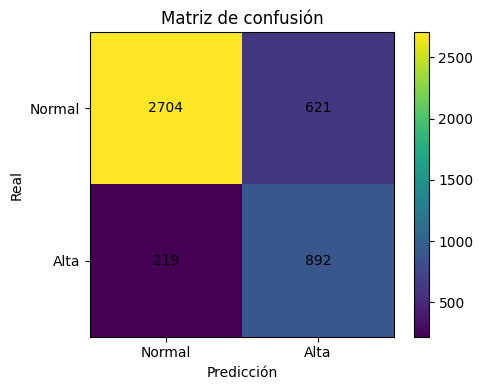

              precision    recall  f1-score   support

      Normal       0.93      0.81      0.87      3325
        Alta       0.59      0.80      0.68      1111

    accuracy                           0.81      4436
   macro avg       0.76      0.81      0.77      4436
weighted avg       0.84      0.81      0.82      4436



In [19]:
cm = confusion_matrix(yc_test, pred_cls)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm)
ax.set_title("Matriz de confusión")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks([0,1], ["Normal","Alta"])
ax.set_yticks([0,1], ["Normal","Alta"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center")
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(classification_report(yc_test, pred_cls, target_names=["Normal","Alta"], zero_division=0))

## 19. Regresión: estimar pasos por hora

Se comparan Regresión Lineal y Random Forest. MAE expresa el error promedio directamente en pasos; RMSE penaliza errores grandes; R² mide variabilidad explicada.

In [20]:
Xr = df_ml[features]
yr = df_ml["StepTotal"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=parametros["test_size"], random_state=parametros["semilla"]
)

modelos_reg = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200, max_depth=14, min_samples_leaf=3,
        random_state=42, n_jobs=-1
    )
}

filas = []
pipes_reg = {}

for nombre, modelo in modelos_reg.items():
    pipe = Pipeline([("pre", pre), ("modelo", modelo)])
    pipe.fit(Xr_train, yr_train)
    pred = pipe.predict(Xr_test)
    filas.append({
        "modelo": nombre,
        "MAE_pasos": mean_absolute_error(yr_test, pred),
        "RMSE_pasos": np.sqrt(mean_squared_error(yr_test, pred)),
        "R2": r2_score(yr_test, pred)
    })
    pipes_reg[nombre] = pipe

resultados_reg = pd.DataFrame(filas).sort_values("MAE_pasos")
resultados_reg

,modelo,MAE_pasos,RMSE_pasos,R2
1,RandomForestRegressor,158.747201,256.651712,0.423144
0,LinearRegression,214.616848,294.634788,0.239766


## 20. Tuning de regresión

In [21]:
pipe_rf_reg = Pipeline([
    ("pre", pre),
    ("modelo", RandomForestRegressor(random_state=42, n_jobs=-1))
])

grid_reg = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [10, 16, None],
    "modelo__min_samples_leaf": [2, 5]
}

search_reg = GridSearchCV(
    pipe_rf_reg, grid_reg,
    scoring="neg_mean_absolute_error", cv=3, n_jobs=-1
)
search_reg.fit(Xr_train, yr_train)
mejor_regresor = search_reg.best_estimator_
pred_reg = mejor_regresor.predict(Xr_test)

metricas_reg_final = {
    "MAE_pasos": mean_absolute_error(yr_test, pred_reg),
    "RMSE_pasos": np.sqrt(mean_squared_error(yr_test, pred_reg)),
    "R2": r2_score(yr_test, pred_reg)
}

print("Mejores parámetros:", search_reg.best_params_)
pd.DataFrame([metricas_reg_final])

Mejores parámetros: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 200}


,MAE_pasos,RMSE_pasos,R2
0,158.603511,254.543506,0.432582


## 21. Interpretabilidad del modelo

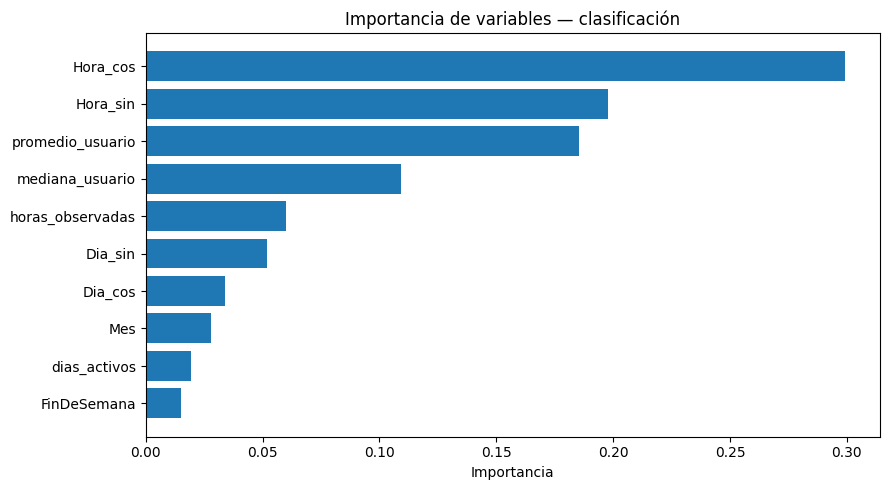

,variable,importancia
1,Hora_cos,0.299252
0,Hora_sin,0.197876
6,promedio_usuario,0.185472
7,mediana_usuario,0.109055
8,horas_observadas,0.060137
2,Dia_sin,0.051898
3,Dia_cos,0.033936
5,Mes,0.027780
9,dias_activos,0.019430
4,FinDeSemana,0.015165


In [22]:
importancias = pd.DataFrame({
    "variable": features,
    "importancia": mejor_clasificador.named_steps["modelo"].feature_importances_
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(9,5))
plt.barh(importancias["variable"].iloc[::-1], importancias["importancia"].iloc[::-1])
plt.title("Importancia de variables — clasificación")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

importancias

## 22. KPIs y visualizaciones ejecutivas

In [23]:
promedio_hora = df_integrado.groupby("Hora")["StepTotal"].mean().sort_values(ascending=False)

kpis = {
    "fecha_generacion": datetime.now().isoformat(timespec="seconds"),
    "registros": int(len(df_integrado)),
    "usuarios": int(df_integrado["Id"].nunique()),
    "promedio_pasos_hora": round(float(df_integrado["StepTotal"].mean()), 2),
    "mediana_pasos_hora": round(float(df_integrado["StepTotal"].median()), 2),
    "hora_mayor_actividad": int(promedio_hora.index[0]),
    "f1_clasificacion": round(float(metricas_cls_final["f1"]), 4),
    "roc_auc": round(float(metricas_cls_final["roc_auc"]), 4),
    "mae_regresion_pasos": round(float(metricas_reg_final["MAE_pasos"]), 2),
    "r2_regresion": round(float(metricas_reg_final["R2"]), 4)
}

pd.DataFrame([kpis]).T.rename(columns={0:"valor"})

,valor
fecha_generacion,2026-07-10T02:07:33
registros,22179
usuarios,34
promedio_pasos_hora,210.93
mediana_pasos_hora,10.0
hora_mayor_actividad,18
f1_clasificacion,0.6799
roc_auc,0.8872
mae_regresion_pasos,158.6
r2_regresion,0.4326


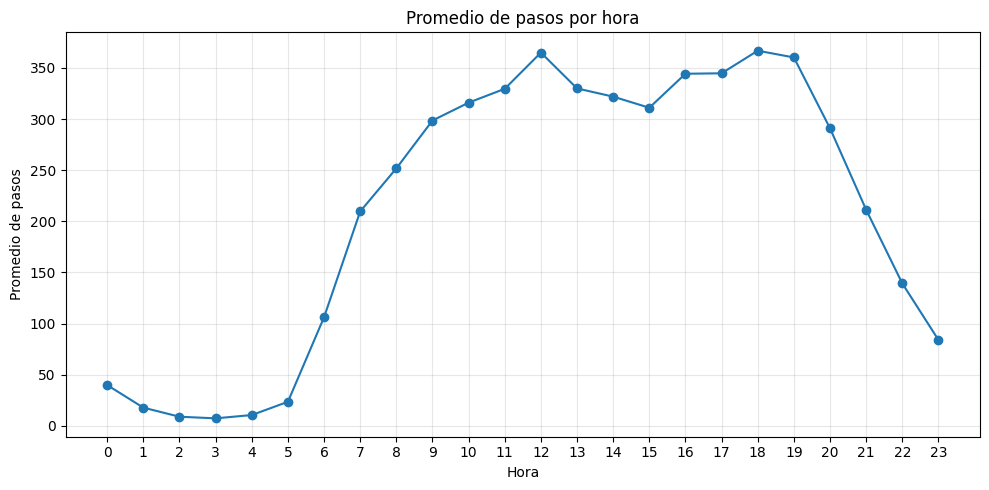

In [24]:
serie_hora = df_integrado.groupby("Hora")["StepTotal"].mean()
plt.figure(figsize=(10,5))
plt.plot(serie_hora.index, serie_hora.values, marker="o")
plt.title("Promedio de pasos por hora")
plt.xlabel("Hora")
plt.ylabel("Promedio de pasos")
plt.xticks(range(24))
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

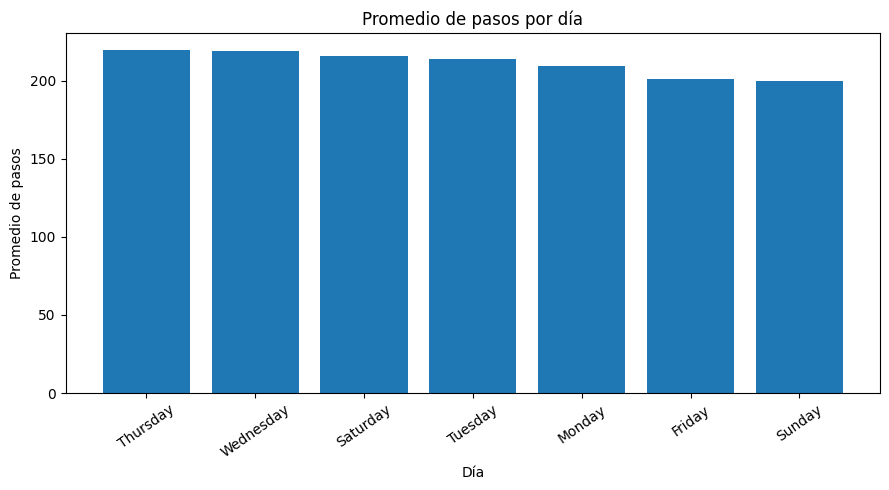

In [25]:
serie_dia = df_integrado.groupby("Dia", observed=True)["StepTotal"].mean().sort_values(ascending=False)
plt.figure(figsize=(9,5))
plt.bar(serie_dia.index.astype(str), serie_dia.values)
plt.title("Promedio de pasos por día")
plt.xlabel("Día")
plt.ylabel("Promedio de pasos")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

## 23. Exportación para API, dashboard y GitHub

In [26]:
OUTPUT_DATA = DATA_PROCESSED / "hourlySteps_eft_final.csv"
OUTPUT_KPIS = RESULTS_DIR / "kpis_eft.json"
OUTPUT_CLS = RESULTS_DIR / "metricas_clasificacion.csv"
OUTPUT_REG = RESULTS_DIR / "metricas_regresion.csv"
OUTPUT_IMPORT = RESULTS_DIR / "importancia_variables.csv"
MODEL_CLS = MODELS_DIR / "clasificador_actividad.joblib"
MODEL_REG = MODELS_DIR / "regresor_pasos.joblib"

export = df_integrado.copy()
export["Fecha"] = export["Fecha"].astype(str)
export.to_csv(OUTPUT_DATA, index=False)

with open(OUTPUT_KPIS, "w", encoding="utf-8") as f:
    json.dump(kpis, f, indent=2, ensure_ascii=False)

resultados_cls.to_csv(OUTPUT_CLS, index=False)
resultados_reg.to_csv(OUTPUT_REG, index=False)
importancias.to_csv(OUTPUT_IMPORT, index=False)
joblib.dump(mejor_clasificador, MODEL_CLS)
joblib.dump(mejor_regresor, MODEL_REG)

artefactos = pd.DataFrame({
    "archivo": [OUTPUT_DATA, OUTPUT_KPIS, OUTPUT_CLS, OUTPUT_REG, OUTPUT_IMPORT, MODEL_CLS, MODEL_REG, LOG_PATH]
})
artefactos["existe"] = artefactos["archivo"].apply(lambda p: Path(p).exists())
artefactos["kb"] = artefactos["archivo"].apply(lambda p: round(Path(p).stat().st_size/1024, 2))
artefactos

,archivo,existe,kb
0,/content/proyecto1/data/processed/hourlySteps_...,True,4220.08
1,/content/proyecto1/results/kpis_eft.json,True,0.28
2,/content/proyecto1/results/metricas_clasificac...,True,0.27
3,/content/proyecto1/results/metricas_regresion.csv,True,0.18
4,/content/proyecto1/results/importancia_variabl...,True,0.33
5,/content/proyecto1/models/clasificador_activid...,True,34245.37
6,/content/proyecto1/models/regresor_pasos.joblib,True,40637.75
7,/content/proyecto1/logs/eft_pipeline.log,True,0.31


## 24. Validación final

In [27]:
validaciones = {
    "dataset_no_vacio": not df_integrado.empty,
    "sin_nulos_criticos": df_integrado[COLUMNAS_BASE].isna().sum().sum() == 0,
    "sin_duplicados_clave": df_integrado.duplicated(["Id","ActivityHour"]).sum() == 0,
    "sin_pasos_negativos": bool((df_integrado["StepTotal"] >= 0).all()),
    "join_sin_perdida": len(df_integrado) == len(df_etl),
    "modelo_clasificacion": MODEL_CLS.exists(),
    "modelo_regresion": MODEL_REG.exists(),
    "kpis_exportados": OUTPUT_KPIS.exists()
}

reporte = pd.DataFrame(validaciones.items(), columns=["validación","resultado"])
assert reporte["resultado"].all(), "Existe una validación final fallida"
logger.info("Pipeline EFT completado correctamente")
reporte

2026-07-10 02:07:34,641 | INFO | Pipeline EFT completado correctamente
INFO:eft_pipeline:Pipeline EFT completado correctamente


,validación,resultado
0,dataset_no_vacio,True
1,sin_nulos_criticos,True
2,sin_duplicados_clave,True
3,sin_pasos_negativos,True
4,join_sin_perdida,True
5,modelo_clasificacion,True
6,modelo_regresion,True
7,kpis_exportados,True


## 25. Conclusiones para la defensa

### Técnicas

- Se integraron tres CSV, SQLite y una fuente JSON tipo API.
- La limpieza fue validada antes y después con métricas objetivas.
- Se demostraron filtros avanzados, agrupaciones, joins, pivot, melt, chunking y vectorización.
- Se entrenaron modelos de clasificación y regresión dentro de pipelines reproducibles.
- Se aplicaron validación cruzada, tuning y métricas contextualizadas.
- Los modelos y KPIs se exportaron para API y dashboard.

### Negocio

- Permite detectar horas con alta actividad.
- Facilita recomendaciones personalizadas y alertas de sedentarismo.
- Entrega KPIs para seguimiento ejecutivo.
- Convierte datos horarios en información útil para decisiones de bienestar.

### Limitaciones

- El dataset representa una población y período específicos.
- El umbral de actividad alta es estadístico, no clínico.
- La importancia de variables no demuestra causalidad.
- Producción requiere monitoreo de drift, autenticación y pruebas de carga.

## 26. Estructura recomendada en GitHub

```text
proyecto1/
├── api/
├── dashboards/
├── data/
│   ├── raw/
│   ├── og/
│   └── processed/
├── docker/
├── docs/
├── models/
├── notebooks/
│   └── 06_eft_pipeline_ml_end_to_end.ipynb
├── results/
├── src/
├── tests/
├── .github/workflows/
├── .env.example
├── requirements.txt
└── README.md
```